<a href="https://colab.research.google.com/github/Hernandez484/01.01-PROYECTO-KAGGLE/blob/main/02%20-%20preprocesado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

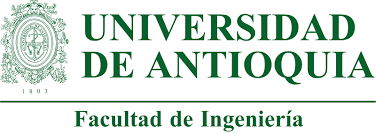

# <font color='056938'> **01.01 - PROYECTO KAGGLE - </font> <font color='8EC044'> Entrega 2** </font>

## <font color='157699'> **Paso 1:** </font>

In [ ]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

## <font color='157699'> **Paso 2: Descargar datos directamente desde Kaggle** </font>

- Se creo un archivo kaggle.jsoncon con mi token de autenticación (en kaggle $\to$ Hago clic en el icono de usuario en la parte superior derecha $\to$
ajustes $\to$ API crea un nuevo token);

- Subirlo a este espacio de trabajo del cuaderno;

- Y ejecutar la siguiente celda.

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download -c udea-ai4eng-20242

 94% 19.0M/20.1M [00:00<00:00, 199MB/s]
100% 20.1M/20.1M [00:00<00:00, 204MB/s]


## <font color='157699'> **Paso 3: Descomprimir e inspeccionar datos** </font>

Se descomprime el fichero.

In [ ]:
!unzip udea*.zip > /dev/null

In [ ]:
!wc *.csv

   296787    296787   4716673 submission_example.csv
   296787   4565553  50135751 test.csv
   692501  10666231 118025055 train.csv
  1286075  15528571 172877479 total


## <font color='157699'> **Paso 4: Se carga `train.csv` con la librería `Pandas`** </font>

In [ ]:
import pandas as pd
import numpy as np

z = pd.read_csv("train.csv")
print ("shape of loaded dataframe", z.shape)

shape of loaded dataframe (692500, 12)


## <font color='157699'> **Paso 5: Información General** </font>

A continuación, se demuestra el preprocesamiento de los datos que incluyen las 11 columnas de los atributos. Este proceso es fundamental para preparar el conjunto de datos antes de aplicar los dos modelos de clasificación propuestos. Los pasos incluyen manejo de valores faltantes, transformación de variables categóricas y numéricas, normalización, y creación de variables codificadas.

### <font color='157'> **1. Análisis de Datos Faltantes y Limpieza Inicial** </font>

Primero se deben verificar los datos faltantes y limpiar aquellos valores que no aportan información, como "No sabe" o "No aplica". Estos se reemplazan por un valor genérico, como "No info". También se imputan los valores faltantes con "No info".

In [ ]:
# Verificar datos faltantes
print(z.isnull().sum())

# Reemplazar valores "No sabe", "No aplica" por "No info"
z.replace(['No sabe', 'No aplica'], 'No info', inplace=True)

# Rellenar valores faltantes con una categoría genérica "No info"
z.fillna('No info', inplace=True)

ID                                    0
PERIODO                               0
ESTU_PRGM_ACADEMICO                   0
ESTU_PRGM_DEPARTAMENTO                0
ESTU_VALORMATRICULAUNIVERSIDAD     6287
ESTU_HORASSEMANATRABAJA           30857
FAMI_ESTRATOVIVIENDA              32137
FAMI_TIENEINTERNET                26629
FAMI_EDUCACIONPADRE               23178
FAMI_EDUCACIONMADRE               23664
ESTU_PAGOMATRICULAPROPIO           6498
RENDIMIENTO_GLOBAL                    0
dtype: int64


**Explicación:**

- Este paso garantiza que no haya valores nulos o indeterminados en las columnas.

- Reemplazar con "No info" facilita el manejo de datos categóricos para la imputación y posterior transformación.

### <font color='157'> **2. Conversión de Variables Cualitativas a Cuantitativas** </font>

Para trabajar con los modelos, las variables categóricas deben ser convertidas a valores numéricos. Aquí se utilizan las técnicas como Label Encoding y One-Hot Encoding.

Atributos a transformar:

   - **FAMI_ESTRATOVIVIENDA (Estrato):** Es una variable ordinal (1 a 6), se utiliza Label Encoding.

   - **FAMI_EDUCACIONPADRE y FAMI_EDUCACIONMADRE (Nivel educativo):** También son variables ordinales que reflejan el nivel educativo.

   - **FAMI_TIENEINTERNET y ESTU_PAGOMATRICULAPROPIO:** Son variables binarias (Sí/No) y se pueden mapear directamente a 1 y 0.
   
   - **ESTU_HORASSEMANATRABAJA y ESTU_VALORMATRICULAUNIVERSIDAD:** Se deben convertir a rangos y luego a valores categóricos.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Codificación ordinal para FAMI_ESTRATOVIVIENDA, FAMI_EDUCACIONPADRE y FAMI_EDUCACIONMADRE
le_estrato = LabelEncoder()
z['FAMI_ESTRATOVIVIENDA'] = le_estrato.fit_transform(z['FAMI_ESTRATOVIVIENDA'].astype(str).replace('No info', -1).astype(str))

le_educacion = LabelEncoder()
z['FAMI_EDUCACIONPADRE'] = le_educacion.fit_transform(z['FAMI_EDUCACIONPADRE'].astype(str).replace('No info', -1).astype(str))
z['FAMI_EDUCACIONMADRE'] = le_educacion.fit_transform(z['FAMI_EDUCACIONMADRE'].astype(str).replace('No info', -1).astype(str))

# Codificación binaria para FAMI_TIENEINTERNET y ESTU_PAGOMATRICULAPROPIO
z['FAMI_TIENEINTERNET'] = z['FAMI_TIENEINTERNET'].map({'Sí': 1, 'No': 0, 'No info': -1})
z['ESTU_PAGOMATRICULAPROPIO'] = z['ESTU_PAGOMATRICULAPROPIO'].map({'Sí': 1, 'No': 0, 'No info': -1})

# Convertir ESTU_HORASSEMANATRABAJA en rangos categóricos
z['ESTU_HORASSEMANATRABAJA'] = pd.to_numeric(z['ESTU_HORASSEMANATRABAJA'], errors='coerce').fillna(-1)
z.loc[z['ESTU_HORASSEMANATRABAJA'] != -1, 'ESTU_HORASSEMANATRABAJA'] = pd.cut(
    z.loc[z['ESTU_HORASSEMANATRABAJA'] != -1, 'ESTU_HORASSEMANATRABAJA'],
    bins=[0, 10, 20, 30, 40],
    labels=[0, 1, 2, 3],
    right=False,
    include_lowest=True
).astype(int)

# Convertir ESTU_VALORMATRICULAUNIVERSIDAD en rangos categóricos
z['ESTU_VALORMATRICULAUNIVERSIDAD'] = pd.to_numeric(z['ESTU_VALORMATRICULAUNIVERSIDAD'], errors='coerce').fillna(-1)
z.loc[z['ESTU_VALORMATRICULAUNIVERSIDAD'] != -1, 'ESTU_VALORMATRICULAUNIVERSIDAD'] = pd.cut(
    z.loc[z['ESTU_VALORMATRICULAUNIVERSIDAD'] != -1, 'ESTU_VALORMATRICULAUNIVERSIDAD'],
    bins=[0, 5000000, 10000000, float('inf')],
    labels=[0, 1, 2],
    right=False,
    include_lowest=True
).astype(int)

z.head()

,ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO,RENDIMIENTO_GLOBAL
0,904256,20212,ENFERMERIA,BOGOTÁ,-1.0,-1.0,3,NaN,11,5,0.0,medio-alto
1,645256,20212,DERECHO,ATLANTICO,-1.0,0.0,3,0.0,10,11,0.0,bajo
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,-1.0,-1.0,3,NaN,8,8,0.0,bajo
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,-1.0,0.0,4,NaN,0,8,0.0,alto
4,989032,20212,PSICOLOGIA,ANTIOQUIA,-1.0,-1.0,3,NaN,6,6,0.0,medio-bajo


**Explicación:**

- *Label Encoding:* Transforma variables categóricas ordinales en valores numéricos, manteniendo el orden lógico.

- *One-Hot Encoding:* No se aplica en este paso porque no hemos tratado variables nominales de múltiples clases todavía.

- *Normalización por rangos:* Agrupamos horas trabajadas y valores de matrícula en intervalos para manejar las diferencias de magnitudes.

### <font color='157'> **3. One-Hot Encoding para Variables Nominales Multiclase** </font>

Para variables con múltiples categorías sin un orden lógico, se aplica One-Hot Encoding. Esto es necesario para variables como el programa académico y el departamento.

In [ ]:
# One-Hot Encoding para ESTU_PRGM_ACADEMICO y ESTU_PRGM_DEPARTAMENTO
z = pd.get_dummies(z, columns=['ESTU_PRGM_ACADEMICO', 'ESTU_PRGM_DEPARTAMENTO'], drop_first=True)

**Explicación:**

- One-Hot Encoding: Crea columnas nuevas, una para cada categoría dentro de las variables nominales. Así, el modelo puede manejar múltiples categorías sin imponerles un orden numérico incorrecto.

### <font color='157'> **4. Normalización de Datos Cuantitativos** </font>

Es importante escalar los datos cuantitativos para que estén en un rango similar y no haya variables que dominen a otras. Se utiliza MinMaxScaler para normalizar las variables continuas entre 0 y 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Crear un scaler para normalizar valores numéricos
scaler = MinMaxScaler()

# Normalizar PERIODO, ESTU_HORASSEMANATRABAJA y ESTU_VALORMATRICULAUNIVERSIDAD
z[['PERIODO', 'ESTU_HORASSEMANATRABAJA', 'ESTU_VALORMATRICULAUNIVERSIDAD']] = scaler.fit_transform(
    z[['PERIODO', 'ESTU_HORASSEMANATRABAJA', 'ESTU_VALORMATRICULAUNIVERSIDAD']])

**Explicación:**

- La normalización asegura que las variables numéricas se encuentren en un rango similar (0-1). Esto es crucial para modelos como K-Nearest Neighbors (KNN), donde las distancias juegan un papel fundamental.

### <font color='157'> **5. División de Conjunto de Datos y Preparación para Kaggle** </font>

Finalmente, se divide el conjunto de datos en entrenamiento y prueba, para evaluar el rendimiento del modelo en datos no vistos durante el entrenamiento.

In [ ]:
from sklearn.model_selection import train_test_split

# Separar características predictivas (X) y la etiqueta (y)
X = z.drop(columns=['RENDIMIENTO_GLOBAL'])  # Características
y = z['RENDIMIENTO_GLOBAL']  # Etiqueta

# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Resumen del Preprocesamiento:**

- Análisis de Datos Faltantes y Limpieza: Se manejan los valores "No sabe", "No aplica" y valores faltantes.

- Conversión de Variables Categóricas a Cuantitativas: Se codifican las variables ordinales y se aplican técnicas de binarización.

- One-Hot Encoding: Se transforman variables nominales multicategoría en múltiples columnas binarias.

- Normalización: Las variables numéricas son escaladas para estar en un rango uniforme.

- División de Datos: Se dividen los datos en conjuntos de entrenamiento y prueba.